1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Sampling Your Data
4. Build Model:
- Try DecisionTree
- Try RandomForest
5. Perform model on training set and test set using gridsearch CV
6. Measure performance of the model.
7. Which metric is your main metric for this problem and why? What is your main model as well as their params and why?


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

** Submit Link **: https://forms.gle/aAjeG25RPUtQHijs9

Churn rate is a marketing metric that describes the number of customers who leave a business over a specific time period. Every user is assigned a prediction value that estimates their state of churn at any given time. This value is based on:

Age- Age Of The Customer

Employment Type- The Sector In Which Customer Is Employed

GraduateOrNot- Whether The Customer Is College Graduate Or Not

AnnualIncome- The Yearly Income Of The Customer In Indian Rupees[Rounded To Nearest 50 Thousand Rupees]

FamilyMembers- Number Of Members In Customer's Family

ChronicDisease- Whether The Customer Suffers From Any Major Disease Or
Conditions Like Diabetes/High BP or Asthama,etc.

FrequentFlyer- Derived Data Based On Customer's History Of Booking Air Tickets On Atleast 4 Different Instances In The Last 2 Years[2017-2019].

EverTravelledAbroad- Has The Customer Ever Travelled To A Foreign Country[Not Necessarily Using The Company's Services]

TravelInsurance- Did The Customer Buy Travel Insurance Package During Introductory Offering Held In The Year 2019.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive

# drive.mount("/content/drive")

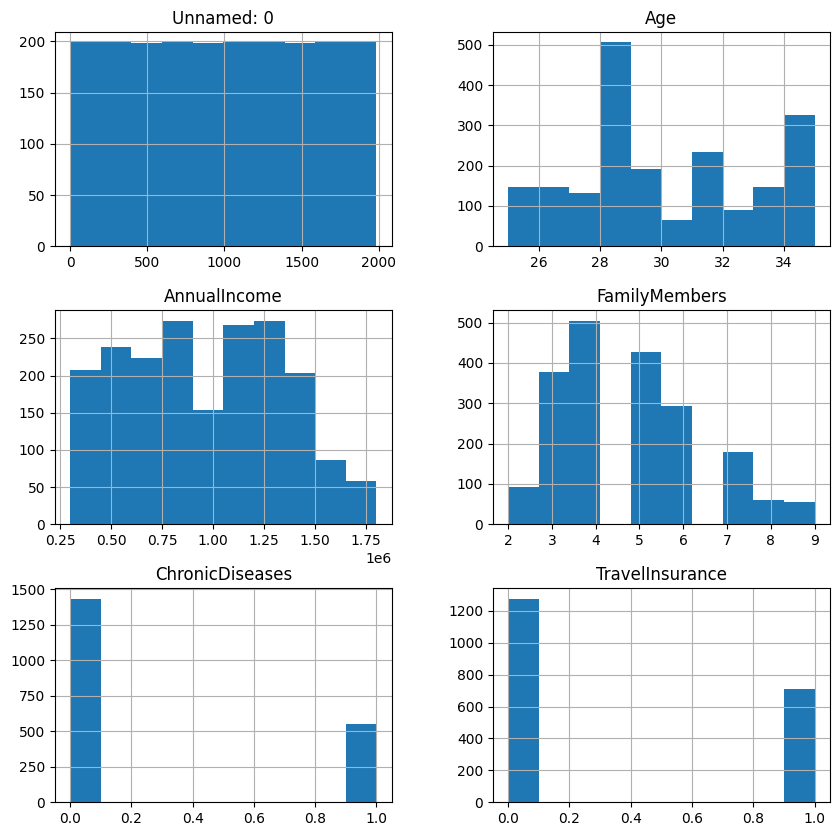

In [2]:
import pandas as pd
PATH = "D:/Introduction-to-Machine-Learning_MTH10353/Homework/4/TravelInsurancePrediction.csv" # Path to your file

df = pd.read_csv(PATH)
df.head()
#ToDo: Show histogram of dataframe
df.hist(figsize=(10, 10))
plt.show()

## Data Analysis

In [3]:
# Data analysis
# Todo: analyze your data here

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


In [5]:
df.describe()

,Unnamed: 0,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,993.000000,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,573.741812,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


In [6]:
for column in df.columns:
    if df[column].nunique() <= 10:
        print(f"Unique values for column '{column}': {df[column].unique()}")
        

Unique values for column 'Employment Type': ['Government Sector' 'Private Sector/Self Employed']
Unique values for column 'GraduateOrNot': ['Yes' 'No']
Unique values for column 'FamilyMembers': [6 7 4 3 8 9 5 2]
Unique values for column 'ChronicDiseases': [1 0]
Unique values for column 'FrequentFlyer': ['No' 'Yes']
Unique values for column 'EverTravelledAbroad': ['No' 'Yes']
Unique values for column 'TravelInsurance': [0 1]


In [7]:
print("Missing values:")
df.isnull().sum()

Missing values:


Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [8]:
print("Invalid values:")
print(df[df["Age"] < 0])
print(df[df["AnnualIncome"] < 0])
print(df[df["FamilyMembers"] < 0])
print(df[df["ChronicDiseases"] < 0])
print(df[df["TravelInsurance"] < 0])

Invalid values:
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, Age, Employment Type, GraduateOrNot, AnnualIncome, FamilyMembers, ChronicDiseases, FrequentFlyer, EverTravelledAbroad, TravelInsurance]
Index: []


Remove the column Unnamed: 0 because we don't need it for our analysis. It is just an index column

In [9]:
# remove column Unnamed: 0
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


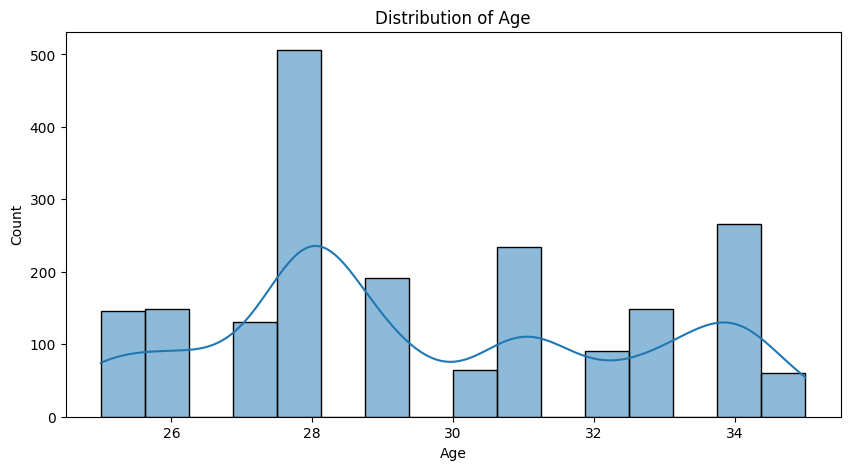

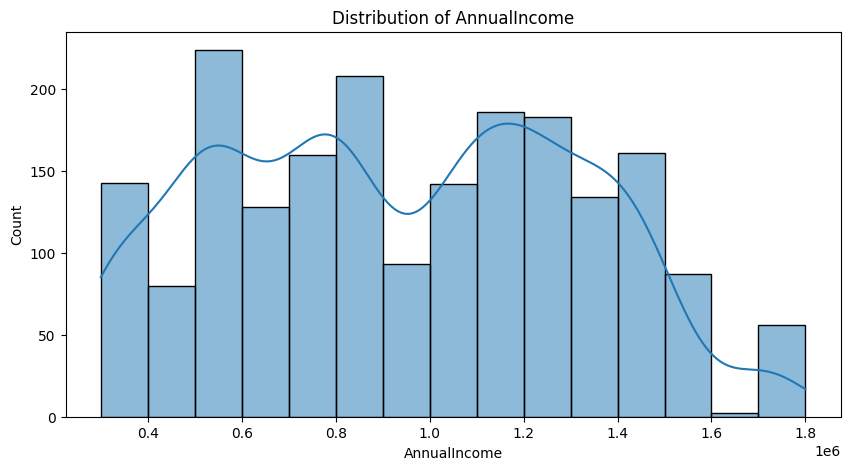

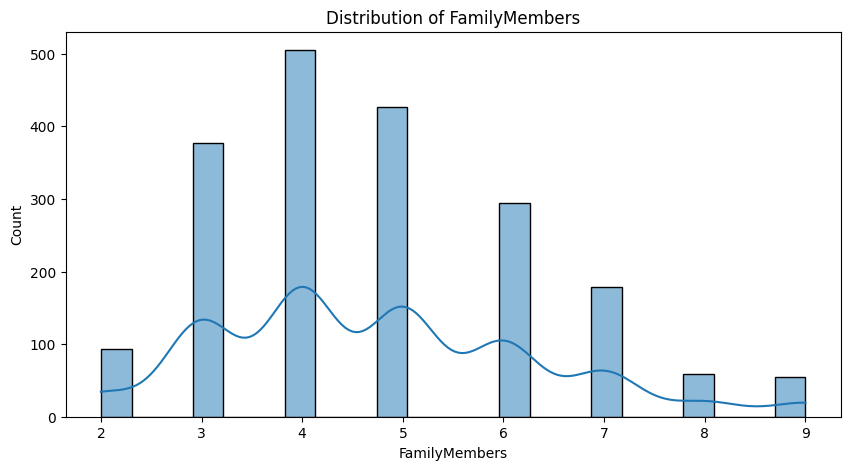

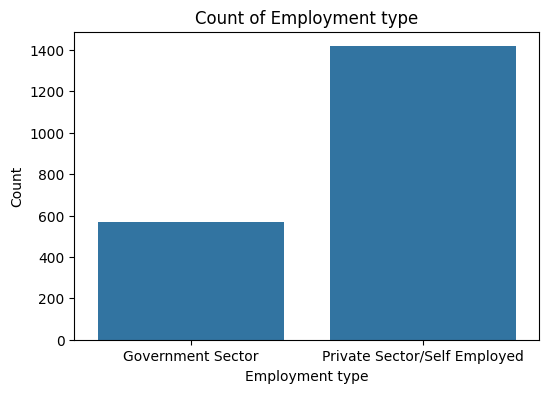

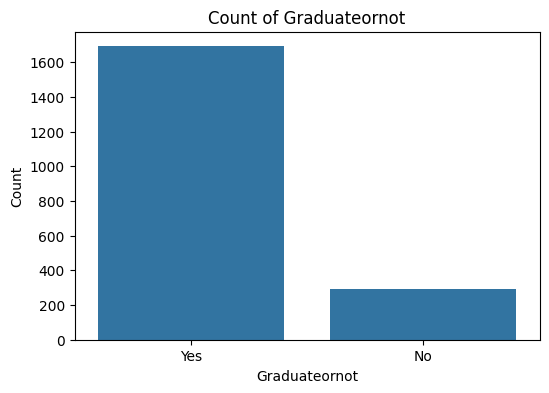

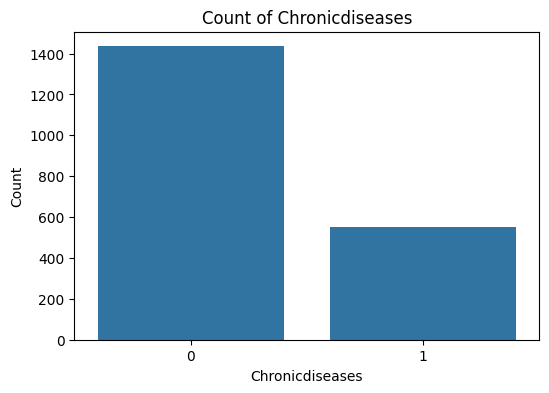

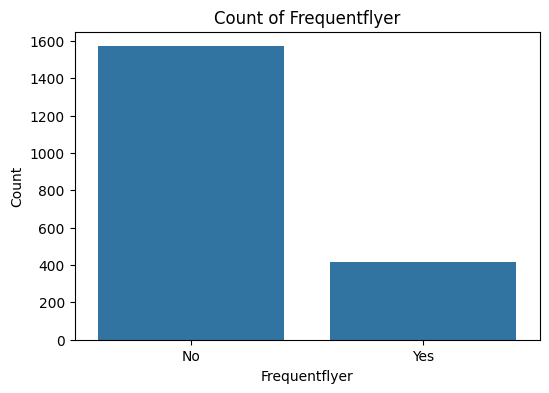

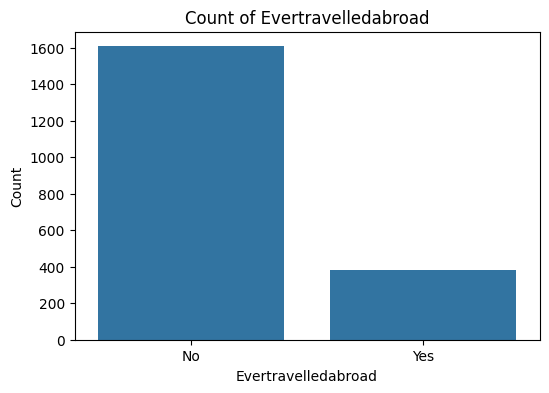

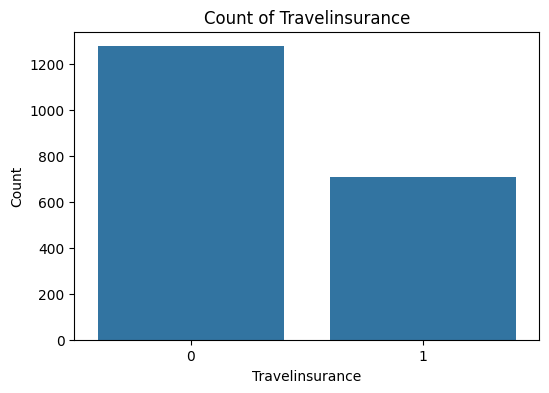

In [10]:
from matplotlib import pyplot as plt
import seaborn as sns


non_binary_columns = [col for col in df.columns if df[col].nunique() > 2]
for column in non_binary_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

binary_columns = [col for col in df.columns if df[col].nunique() == 2]
for column in binary_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[column])
    plt.title(f'Count of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Count')
    plt.show()



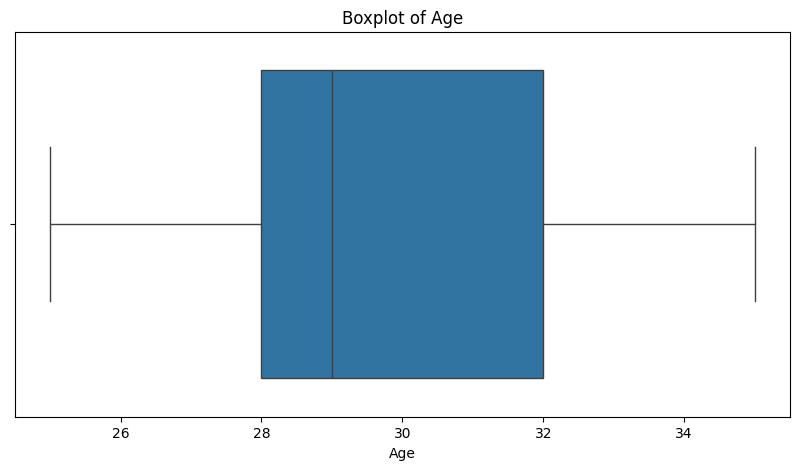

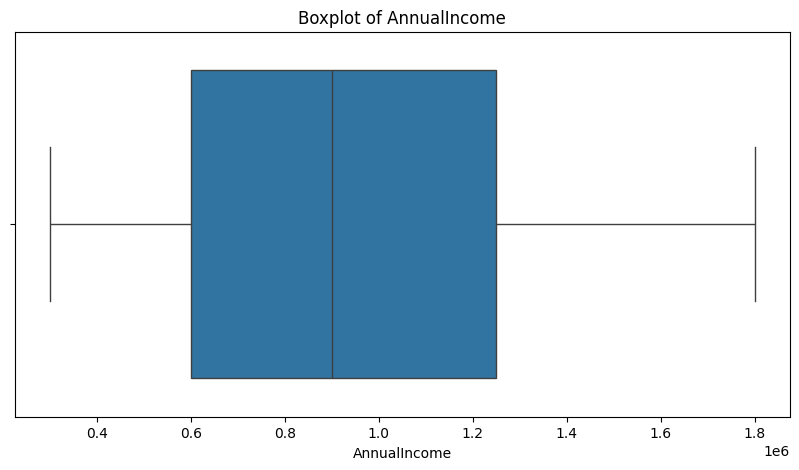

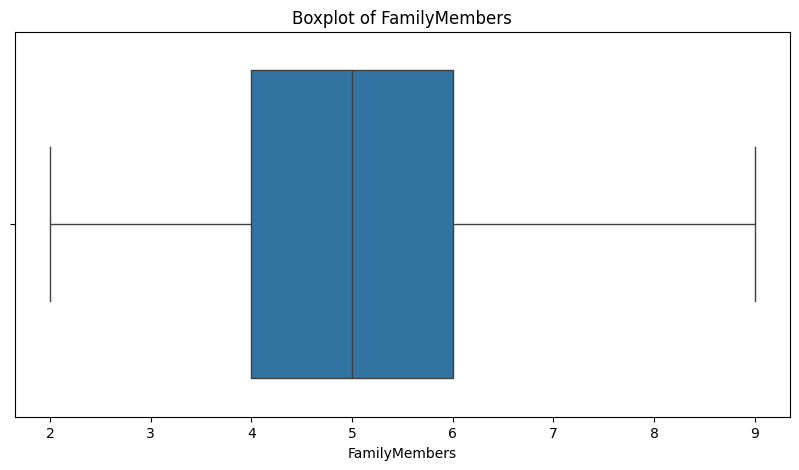

In [11]:
for column in non_binary_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()
    

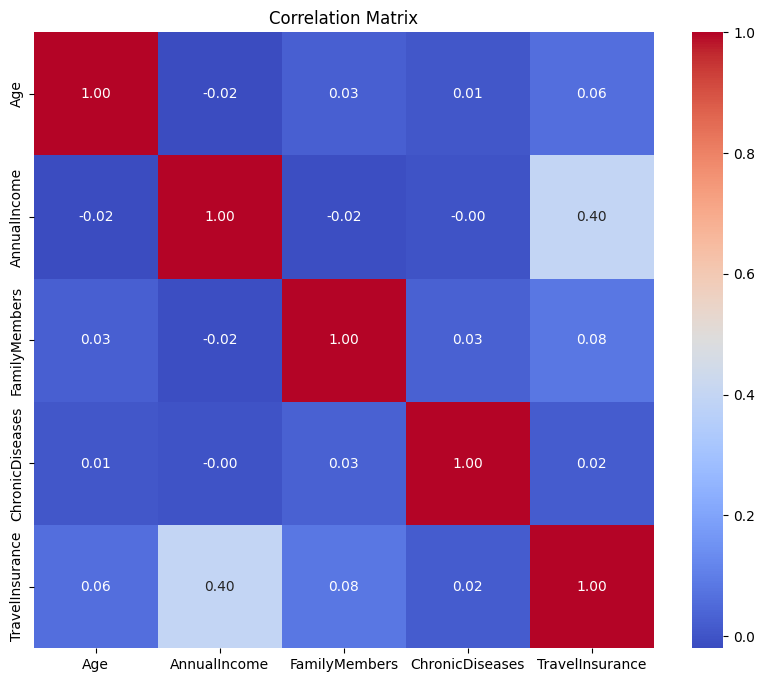

In [12]:
plt.figure(figsize=(10,8))

# Tính ma trận tương quan giữa các biến số
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numerical_cols].corr()

# Heatmap để visualize tương quan
# annot=True: hiển thị giá trị
# cmap='coolwarm': chọn màu
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## Preprocessing

In [13]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df = df.dropna() # Drop rows with missing values
    return df

In [14]:
df = preprocessing_data(df.copy())

## Feature Engineering

<Axes: >

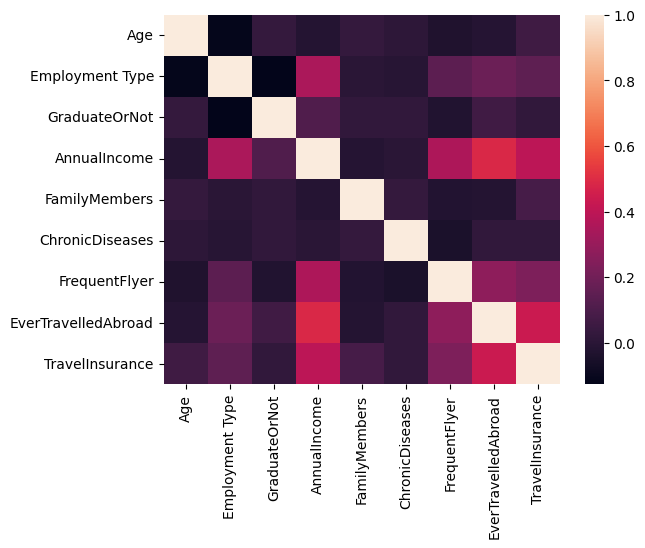

In [15]:
# Heatmap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    # Non numeric columns to numeric
    label_encoder = LabelEncoder()
    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = label_encoder.fit_transform(df[column])
        else:
            df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [16]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = df.drop(['TravelInsurance'], axis=1)
    y = df['TravelInsurance']
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [17]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 69 # funny number
TRAIN_SIZE = 0.7

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

def build_model(X, y, model_type='rf'):
    """
    Design your model and train it using GridSearchCV
    :param X: feature matrix
    :param y: target
    :param model_type: 'dt' hoặc 'rf'
    :return: trained best model
    """
    if model_type == 'dt':
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
        ])
        
        # GridSearch for Decision Tree
        param_grid = {
            'dt__criterion': ['gini', 'entropy'],
            'dt__max_depth': [None, 5, 10, 15, 20],
            'dt__min_samples_split': [2, 5, 10]
        }
        
    elif model_type == 'rf':
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('rf', RandomForestClassifier(random_state=RANDOM_STATE))
        ])
        
        # GridSearch for Random Forest
        param_grid = {
            'rf__n_estimators': [50, 100, 200], 
            'rf__max_depth': [None, 10, 20, 30],
            'rf__min_samples_split': [2, 5, 10]
        }
    else:
        raise ValueError("invalid model_type")

    grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    
    # Fit the model 
    grid_search.fit(X, y)
    print(f"Best parameters found: {grid_search.best_params_}")
    print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}\n")

    return grid_search.best_estimator_


def calculate_performance(y_true, y_pred):
    """
    Đánh giá mô hình
    :param y_true: ground truth values
    :param y_pred: predictions
    :return: main_score
    """
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Precision (weighted): {prec:.4f}")
    print(f"Recall (weighted): {rec:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (weighted): {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    main_score = f1
    return main_score

# 1. Decision Tree
print("DECISION TREE")
dt_model = build_model(trainX, trainY, model_type='dt')
dt_pred = dt_model.predict(testX)
calculate_performance(testY, dt_pred)

# 2. Random Forest
print("RANDOM FOREST")
rf_model = build_model(trainX, trainY, model_type='rf')
rf_pred = rf_model.predict(testX)
calculate_performance(testY, rf_pred)

DECISION TREE
Best parameters found: {'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_split': 2}
Best Cross-Validation F1 Score: 0.8224

Precision (weighted): 0.8419
Recall (weighted): 0.8275
Accuracy: 0.8275
F1 (weighted): 0.8176

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.97      0.87       373
         1.0       0.91      0.60      0.72       224

    accuracy                           0.83       597
   macro avg       0.86      0.78      0.80       597
weighted avg       0.84      0.83      0.82       597

RANDOM FOREST
Best parameters found: {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best Cross-Validation F1 Score: 0.8208

Precision (weighted): 0.8433
Recall (weighted): 0.8308
Accuracy: 0.8308
F1 (weighted): 0.8219

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.96      0.88       373
         1.0       

0.8218937258535248

Confusion Matrix - Decision Tree:
 [[360  13]
 [ 90 134]]


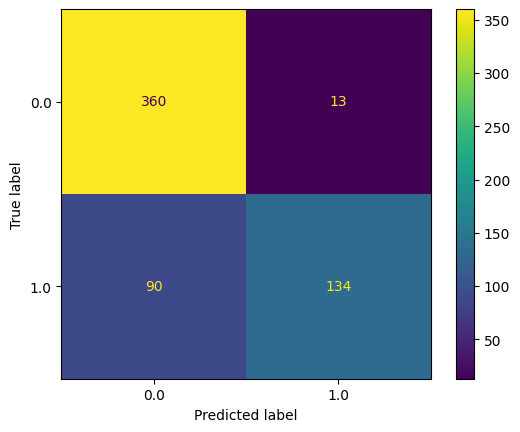

In [19]:
cm = confusion_matrix(testY, dt_pred)
print("Confusion Matrix - Decision Tree:\n", cm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_).plot()


Confusion Matrix - Random Forest:
 [[359  14]
 [ 87 137]]


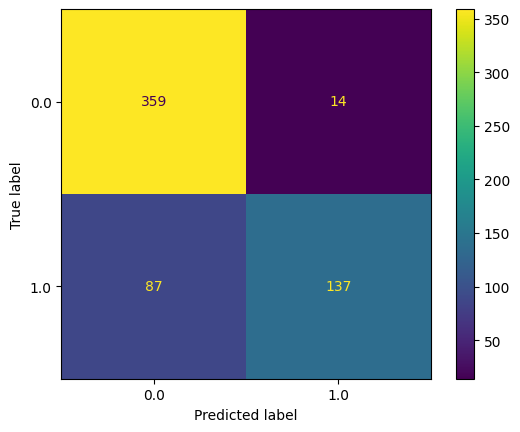

In [20]:
cm = confusion_matrix(testY, rf_pred)
print("Confusion Matrix - Random Forest:\n", cm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_).plot()


In [ ]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return (
        "7.  My main metric is the F1-score because it perfectly balances precision and recall, which is crucial given our imbalanced dataset. "
        "Looking at the support values (Class 0: 373, Class 1: 224), the dataset is moderately imbalanced. Accuracy can be misleading in imbalanced datasets because a model could just predict the majority class and still get a high score. F1-score (weighted) is the best choice because it calculates mean of Precision and Recall giving more weight to the model's performance on the minority class.\n\n"
        "Main model: Random Forest. "
        "Params: {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}. "
        "While the Decision Tree had a fractionally higher Cross-Validation F1 Score during training (0.8224 vs 0.8208), the Random Forest generalized better on the unseen Test data. It achieved a higher weighted F1-score (0.8219 vs 0.8176) and higher Accuracy (0.8308 vs 0.8275). Random Forest's ensemble approach (using 200 trees) makes it much more robust and less prone to overfitting compared to a single Decision Tree.\n\n"
        
        "Other conclusion: Both models struggle to correctly identify the minority class (Class 1.0). While Precision for Class 1.0 is excellent (0.91), the Recall is poor (0.60 for DT, 0.61 for RF). This means that while the model is very confident when it predicts Class 1.0, it completely misses about 39-40% of the actual Class 1.0 instances. In future iterations, we should explore techniques to handle class imbalanceby by tuning the prediction threshold to improve the recall of Class 1.0."
    )

print(get_conclusion())

7. Main metric: F1-score (weighted). Looking at the support values (Class 0: 373, Class 1: 224), the dataset is moderately imbalanced. Accuracy can be misleading in imbalanced datasets because a model could just predict the majority class and still get a high score. F1-score (weighted) is the best choice because it calculates the harmonic mean of Precision and Recall, taking into account the proportion of each class, giving a more realistic view of the model's performance.

Main model: Random Forest. Params: {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}. While the Decision Tree had a fractionally higher Cross-Validation F1 Score during training (0.8224 vs 0.8208), the Random Forest generalized better on the unseen Test data. It achieved a higher weighted F1-score (0.8219 vs 0.8176) and higher Accuracy (0.8308 vs 0.8275). Random Forest's ensemble approach (using 200 trees) makes it much more robust and less prone to overfitting compared to a single Decision